# Read the economic exposure map

A sector name is not a factor portfolio. Compare market, size, value, profitability, investment and momentum sensitivities in their original units, then separate fitted contributions from residual risk.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/models.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
RESULTS = ROOT / 'research/results'
FIGURES = ROOT / 'research/figures'


## Question
What does a technology or utilities label tell us about the fund's economic risks? This chapter uses the historical ten-fund panel, January 2007–July 2026. Full-sample estimates describe that sample; they do not reconstruct historical holdings.

In [2]:
from research.data import FACTORS, load_panel
from research.models import fit_factor_model, hac_ols
x, y, audit = load_panel()
exposures = pd.read_csv(RESULTS / 'exposures.csv').set_index('ticker')
display(exposures.round(3))

,Mkt-RF,SMB,HML,RMW,CMA,Mom,r_squared,residual_vol_annual_pct
ticker,,,,,,,,
IYW,1.157,-0.201,-0.266,-0.172,-0.294,-0.000,0.861,7.544
IYF,1.011,-0.095,0.709,-0.172,-0.265,-0.129,0.891,6.831
IYZ,0.865,0.098,-0.139,0.142,0.432,-0.017,0.587,11.382
IYH,0.731,0.000,-0.156,-0.011,0.344,0.035,0.587,9.290
IYE,0.994,0.291,0.556,0.414,0.399,0.002,0.539,17.769
IYK,0.763,-0.064,-0.025,0.346,0.571,0.008,0.715,7.459
IYJ,1.088,0.194,0.098,0.128,0.144,-0.027,0.909,5.717
IDU,0.599,-0.139,-0.045,0.294,0.355,0.174,0.349,11.680
IYM,1.173,0.147,0.117,0.214,0.294,-0.096,0.743,11.575


## Compare the factor sensitivities
Beta 1 means a one-percentage-point factor return contributes one percentage point to the fitted ETF excess return, conditional on the other factors. A coefficient is not a portfolio weight.

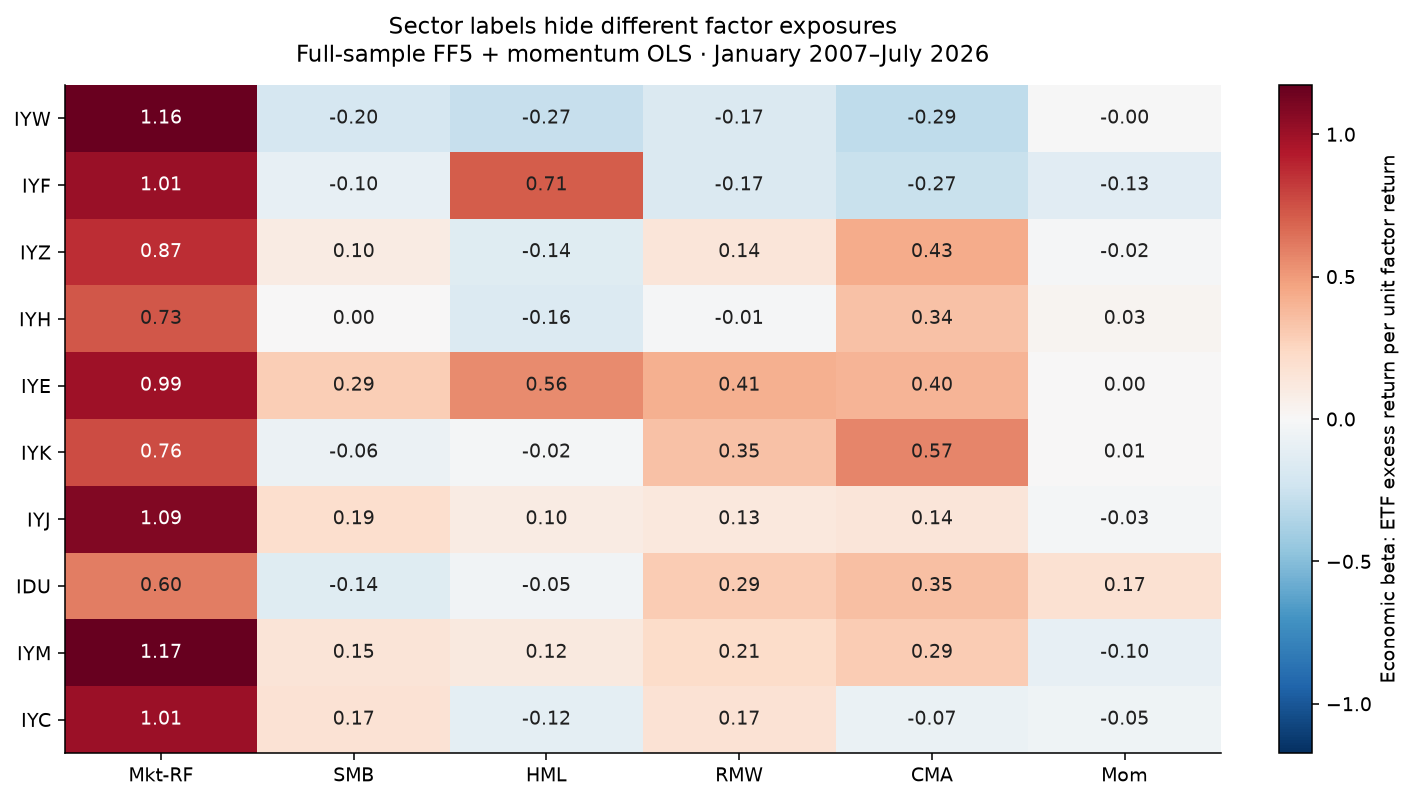

In [3]:
display(Image(filename=str(FIGURES / 'factor_map.png')))

## Reconcile one fund in arithmetic return units
IYW is a fixed teaching example, not the best-looking intercept selected from the table. The intercept, factor contributions and mean residual must reconcile to the mean ETF excess return. These annual arithmetic quantities do not compound to a wealth path.

In [4]:
ticker = 'IYW'
fit = fit_factor_model(x.to_numpy(), y[ticker].to_numpy())
contributions = pd.Series(fit.beta * x.mean().to_numpy(), index=FACTORS)
contributions['Intercept'] = fit.intercept
residual = y[ticker].to_numpy() - fit.predict(x.to_numpy())
contributions['Mean residual'] = residual.mean()
assert np.isclose(contributions.sum(), y[ticker].mean(), atol=1e-12)
display((contributions * 1200).rename('Annual arithmetic contribution (%)').round(3).to_frame())

,Annual arithmetic contribution (%)
Mkt-RF,11.879
SMB,0.081
HML,0.301
RMW,-0.559
CMA,-0.045
Mom,-0.000
Intercept,4.267
Mean residual,-0.000


## How much precision does the value loading have?
The HAC interval is model-conditional and pointwise. Correlated factors can make one coefficient imprecise even when the fitted total return is useful.

In [5]:
inference = hac_ols(x.to_numpy(), y[ticker].to_numpy(), lags=6)
j = FACTORS.index('HML') + 1
value_beta = inference.coefficients[j]
value_se = inference.standard_errors[j]
display(pd.DataFrame({'HML beta': [value_beta], 'Pointwise lower 95%': [value_beta - 1.96*value_se], 'Pointwise upper 95%': [value_beta + 1.96*value_se]}).round(3))

,HML beta,Pointwise lower 95%,Pointwise upper 95%
0,-0.266,-0.418,-0.115


## Interpretation
Energy exposure is not an oil futures position, utilities are not duration alone, and profitability beta is not an accounting screen applied to today's holdings. The fixed model and changing benchmark history limit those interpretations. [Data and fund identity](../../docs/01-data.md) explains the September 2021 changes.